# Hazardous emission detection — texel

Binary classification (hazardous vs. not hazardous) of single-gas presentations from `data/1_600_20`.

**Pipeline** (matches `run_classification_136_train_test.py` and the texel config from the *Continuous emission detection* notebooks):

1. Reduce to the 8 active sensors.
2. Expand to **136** features = raw + ∂¹ + ∂² (24) + 56 ratios + 56 differences.
3. Random HD projection `W_hd ∼ Bernoulli(p_hd)` and **top-k** sparsification.
4. Hebbian readout with `n_out = 2` neurons; the prediction is the argmax output neuron per frame.

**Class mapping (per user):**
- gas 1 (CO) → **hazardous** (class 0)
- gas 2 (Ethylene) → not hazardous (class 1)
- gas 3 (Methane) → not hazardous (class 1)

**Split:** first 450 presentations → train, last 150 → test. Frame-based accuracy reported for each.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

from tools import load

## Gridsearch results — top 5 configurations per evaluation method

Loads `data/hazardous_emission_gridsearch.pkl` (produced by
`run_hazardous_emission_gridsearch.py`) and prints the best 5 (N, k, seed)
runs by test accuracy, separately for the **argmax** and **threshold**
methods.

In [2]:
import pickle, os

GS_PKL = 'data/hazardous_emission_gridsearch.pkl'

if not os.path.exists(GS_PKL):
    print(f'{GS_PKL} not found — run run_hazardous_emission_gridsearch.py first.')
else:
    with open(GS_PKL, 'rb') as f:
        gs = pickle.load(f)
    records = gs['records']
    n_hd_gs = gs.get('config', {}).get('n_hd', None)
    # Backward-compatibility: older pickles store only 'k'.
    for r in records:
        if 's' not in r and n_hd_gs:
            r['s'] = r['k'] / n_hd_gs
    print(f'loaded {len(records)} runs from {GS_PKL}')

    def show_top(records, key, label):
        top = sorted(records, key=lambda r: r[key], reverse=True)[:5]
        print(f'\nTop 5 by {label} test accuracy:')
        print(f'  {"N":>4}  {"s":>6}  {"k":>5}  {"seed":>4}  '
              f'{"acc_train":>10}  {"acc_test":>9}  {"θ*":>8}')
        for r in top:
            thr = f'{r["best_thr"]:.4f}' if key.startswith('acc_thresh') else '   —    '
            tr  = r[key.replace('test', 'train')]
            te  = r[key]
            print(f'  {r["N"]:>4}  {r["s"]:>6.3f}  {r["k"]:>5}  {r["seed"]:>4}  '
                  f'{tr:>10.4f}  {te:>9.4f}  {thr:>8}')

    show_top(records, 'acc_argmax_test',  'argmax')
    show_top(records, 'acc_thresh_test',  'threshold')

loaded 3600 runs from data/hazardous_emission_gridsearch.pkl

Top 5 by argmax test accuracy:
     N       s      k  seed   acc_train   acc_test        θ*
     5   0.100    300    22      1.0000     0.8246     —    
     5   0.100    300    23      1.0000     0.8239     —    
    10   0.100    300    41      0.9368     0.8225     —    
    10   0.100    300    47      0.9737     0.8204     —    
     5   0.100    300     8      1.0000     0.8190     —    

Top 5 by threshold test accuracy:
     N       s      k  seed   acc_train   acc_test        θ*
     2   0.003     10    23      1.0000     0.7401    0.7000
     3   0.003     10    23      1.0000     0.7401    0.7000
     5   0.003     10    23      1.0000     0.7401    0.7000
     2   0.100    300    41      1.0000     0.7313    0.9767
     3   0.100    300    41      1.0000     0.7313    0.9767


In [3]:
top1 = max(records, key=lambda r: r['acc_argmax_test'])
print(top1)

{'seed': np.int64(22), 'N': 5, 'k': 300, 'n_train_frames': 95, 'acc_argmax_train': 1.0, 'acc_argmax_test': 0.824622939319537, 'acc_thresh_train': 1.0, 'acc_thresh_test': 0.7004559803577692, 'best_thr': 0.9866658449172974, 's': 0.1}


## Load sequence and build labels

In [4]:
FILENAME       = '1_600_20_corrected'
N_TRAIN_SEQ    = 10      # first 450 presentations -> train
HAZARDOUS_GAS  = {1}      # CO is the only hazardous gas
GAS_NAMES      = {1: 'CO', 2: 'Ethylene', 3: 'Methane'}
CLASS_NAMES    = {0: 'hazardous', 1: 'not hazardous'}

sensor_data, sequence, times_sec, sequence_sec = load(FILENAME, reduced=True)
h = float(np.median(np.diff(times_sec)))
n_sensors = sensor_data.shape[1]
print(f'sensor_data: {sensor_data.shape}  h={h:.3f}s')
print(f'sequence: {len(sequence)} presentations, gases = {sorted({s[1] for s in sequence})}')
print(f'max inter-presentation gap: {np.diff(sequence_sec).max():.0f}s  '
      f'(continuous after gap correction)')

sensor_data: (11691, 8)  h=1.000s
sequence: 600 presentations, gases = [1, 2, 3]
max inter-presentation gap: 21s  (continuous after gap correction)


In [5]:
# Binary labels per frame: 0 -> hazardous, 1 -> not hazardous, -1 -> unlabeled.
# Train mask: first N_TRAIN_SEQ presentations.
# Test  mask: last  N_TEST_SEQ  presentations (matches the gridsearch script).
N_TEST_SEQ = 50

y_frame    = -np.ones(len(times_sec), dtype=int)
train_mask = np.zeros(len(times_sec), dtype=bool)
test_mask  = np.zeros(len(times_sec), dtype=bool)

test_pres_start = len(sequence) - N_TEST_SEQ
for i, (_, gas) in enumerate(sequence):
    if i + 1 < len(sequence_sec):
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    else:
        flag = (times_sec > sequence_sec[i])
    y_frame[flag] = 0 if int(gas) in HAZARDOUS_GAS else 1
    if i < N_TRAIN_SEQ:
        train_mask[flag] = True
    if i >= test_pres_start:
        test_mask[flag]  = True

labeled = y_frame >= 0
train_mask &= labeled
test_mask  &= labeled

print(f'train frames: {train_mask.sum()}  ({(y_frame[train_mask] == 0).sum()} hazardous, '
      f'{(y_frame[train_mask] == 1).sum()} not hazardous)')
print(f'test  frames: {test_mask.sum()}  ({(y_frame[test_mask] == 0).sum()} hazardous, '
      f'{(y_frame[test_mask] == 1).sum()} not hazardous)')

train frames: 190  (38 hazardous, 152 not hazardous)
test  frames: 951  (304 hazardous, 647 not hazardous)


## Sensor trace expansion (∂¹+∂² + 56R + 56D = 136)

In [6]:
def backward_diff_array(y, h, n):
    coeffs = np.array([(-1) ** kk * comb(n, kk) for kk in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h ** n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = [np.apply_along_axis(lambda c: backward_diff_array(c, h, o),
                                  axis=0, arr=data)
              for o in range(1, max_order + 1)]
    return np.hstack([data] + derivs)


sd = sensor_data.astype(float)
all_pairs = [(i, j) for i in range(n_sensors)
                    for j in range(n_sensors) if i != j]   # 8*7 = 56

deriv  = expand_with_derivatives(sd, h, max_order=2)
ratios = np.column_stack([sd[:, i] / (sd[:, j] + 1e-8) for i, j in all_pairs])
diffs  = np.column_stack([sd[:, i] - sd[:, j]          for i, j in all_pairs])
expanded = np.hstack([deriv, ratios, diffs])
n_dense = expanded.shape[1]
print(f'expanded: {expanded.shape}  (deriv {deriv.shape[1]}, ratios {ratios.shape[1]}, diffs {diffs.shape[1]})')

expanded: (11691, 136)  (deriv 24, ratios 56, diffs 56)


## Expand-and-sparsify network — texel config

Texel parameters (from *Continuous emission detection 2*): `n_hd=10000`, `k=500`, `p_hd=0.025`, `p=1.0`.

In [7]:
n_hd  = 4640
n_out = 2          # neuron 0 -> hazardous, neuron 1 -> not hazardous
s     = 0.1       # sparsity: fraction of HD units active per frame
k     = int(round(s * n_hd))
p     = 1.
p_hd  = 0.025
RNG_SEED = 41

rng = np.random.default_rng(RNG_SEED)
W_hd = rng.binomial(n=1, p=p_hd, size=(n_hd, n_dense)).astype(np.float32)

x_hd  = expanded @ W_hd.T
ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
z_hd  = (ranks < k).astype(np.float32)
print(f'z_hd: {z_hd.shape}  active per frame = {int(z_hd[0].sum())} '
      f'(target k = {k}, s = {s})')

z_hd: (11691, 4640)  active per frame = 464 (target k = 464, s = 0.1)


### Save expand-and-sparsify state

Pickle the random projection `W_hd`, the sparsified activity `z_hd`, and
the per-frame binary labels so downstream readout experiments can reuse
them without rerunning the expansion.

In [8]:
import os, pickle

ES_STATE_PKL = 'data/expand_sparsify_state.pkl'
os.makedirs('data', exist_ok=True)

with open(ES_STATE_PKL, 'wb') as f:
    pickle.dump({
        'W_hd':   W_hd,
        'z_hd':   z_hd,
        'y_frame':    y_frame,
        'train_mask': train_mask,
        'test_mask':  test_mask,
        'times_sec':    times_sec,
        'sequence_sec': sequence_sec,
        'config': {
            'filename':      FILENAME,
            'n_hd':          n_hd,
            'k':             k,
            'p_hd':          p_hd,
            'p':             p,
            'rng_seed':      RNG_SEED,
            'n_train_seq':   N_TRAIN_SEQ,
            'hazardous_gas': sorted(HAZARDOUS_GAS),
        },
    }, f)

print(f'wrote {ES_STATE_PKL}  '
      f'(W_hd: {W_hd.shape}, z_hd: {z_hd.shape}, y_frame: {y_frame.shape})')

wrote data/expand_sparsify_state.pkl  (W_hd: (4640, 136), z_hd: (11691, 4640), y_frame: (11691,))


## Train the Hebbian readout

In [9]:
W_out        = np.zeros((n_out, n_hd), dtype=np.float32)
z_out_online = np.zeros((len(times_sec), n_out), dtype=np.float32)

# Online Hebbian update on training frames; weights freeze afterwards.
# z_out_online[i] uses the W_out as it stands AFTER the update at frame i,
# so activity starts at 0 and grows as training progresses.
for i in range(len(times_sec)):
    if train_mask[i]:
        active = np.flatnonzero(z_hd[i])
        to_flip = active[rng.random(active.size) < p]
        W_out[y_frame[i], to_flip] = 1.0 / k
    z_out_online[i] = z_hd[i] @ W_out.T

print(f'W_out density — hazardous     : {(W_out[0] > 0).mean():.3f}  '
      f'({int((W_out[0] > 0).sum())}/{n_hd})')
print(f'W_out density — not hazardous : {(W_out[1] > 0).mean():.3f}  '
      f'({int((W_out[1] > 0).sum())}/{n_hd})')

W_out density — hazardous     : 0.183  (847/4640)
W_out density — not hazardous : 0.168  (781/4640)


## Frame-based accuracy — train and test

In [10]:
# Accuracy measured with the frozen (final) W_out applied to every frame.
z_out = z_hd @ W_out.T                # (n_frames, 2), values in [0, 1]
pred  = z_out.argmax(axis=1)          # 0 -> hazardous, 1 -> not hazardous

acc_train = (pred[train_mask] == y_frame[train_mask]).mean()
acc_test  = (pred[test_mask]  == y_frame[test_mask]).mean()
print(f'Training accuracy (framewise): {acc_train:.4f}  ({train_mask.sum()} frames)')
print(f'Test     accuracy (framewise): {acc_test:.4f}  ({test_mask.sum()} frames)')

for name, mask in [('train', train_mask), ('test', test_mask)]:
    y_t = y_frame[mask]
    y_p = pred[mask]
    cm  = np.array([[((y_t == a) & (y_p == b)).sum() for b in (0, 1)] for a in (0, 1)])
    print(f'\n{name} confusion matrix (rows = true, cols = pred; 0=hazardous, 1=not):')
    print(cm)

Training accuracy (framewise): 0.9421  (190 frames)
Test     accuracy (framewise): 0.8223  (951 frames)

train confusion matrix (rows = true, cols = pred; 0=hazardous, 1=not):
[[ 38   0]
 [ 11 141]]

test confusion matrix (rows = true, cols = pred; 0=hazardous, 1=not):
[[193 111]
 [ 58 589]]


## Readout activity over the full sequence

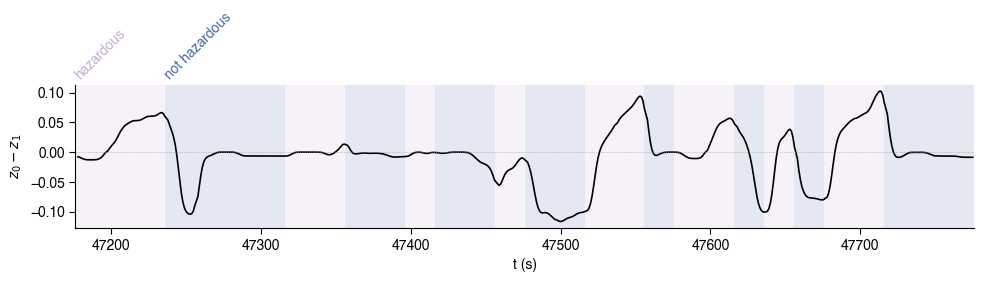

In [11]:
from scipy.ndimage import gaussian_filter1d

# ── Modifiable parameters ──
WINDOW_SECONDS = 600.0   # length of the displayed test window
sigma          = 2.      # Gaussian smoothing of the readout trace

# Per-label x anchor in SECONDS, measured from the LEFT edge of the first
# fully-visible block of each class. Tweak these to nudge each label.
LABEL_X_OFFSET = {
    'hazardous':     5.0,
    'not hazardous': 5.0,
}

# Window: first WINDOW_SECONDS of the test region.
t_lo = float(sequence_sec[N_TRAIN_SEQ])
t_hi = t_lo + WINDOW_SECONDS

# Single trace: hazardous neuron − not-hazardous neuron (uses frozen W_out
# since training has already finished by the test region).
diff = z_out_online[:, 0] - z_out_online[:, 1]
mask_win = (times_sec >= t_lo) & (times_sec <= t_hi)
x = times_sec[mask_win]
y = gaussian_filter1d(diff[mask_win], sigma=sigma)

HAZ_COLOR = 'C3'   # red   — hazardous
NOT_COLOR = 'C0'   # blue  — not hazardous

fig, ax = plt.subplots(figsize=(10, 3))

# Class-region rectangles + record the first FULLY visible block of each
# class so both labels sit on an un-clipped 20 s rectangle.
first_haz_block = None
first_not_block = None
for i, (_, gas) in enumerate(sequence):
    t0 = sequence_sec[i]
    t1 = sequence_sec[i + 1] if i + 1 < len(sequence_sec) else times_sec[-1]
    if t1 < t_lo or t0 > t_hi:
        continue
    is_haz = int(gas) in HAZARDOUS_GAS
    color  = HAZ_COLOR if is_haz else NOT_COLOR
    L, R   = max(t0, t_lo), min(t1, t_hi)
    ax.axvspan(L, R, color=color, alpha=0.15, lw=0)
    fully_visible = (t0 >= t_lo) and (t1 <= t_hi)
    if fully_visible and is_haz and first_haz_block is None:
        first_haz_block = (t0, t1)
    if fully_visible and (not is_haz) and first_not_block is None:
        first_not_block = (t0, t1)

ax.plot(x, y, color='k', lw=1.2)
ax.axhline(0, color='0.6', lw=0.5, linestyle=':')
ax.set_xlim(t_lo, t_hi)
ax.set_xlabel('t (s)')
ax.set_ylabel(r'$z_{0} - z_{1}$')
ax.spines[['top', 'right']].set_visible(False)

# Rotated coloured class labels — anchored at block_start + LABEL_X_OFFSET (s).
y0, y1 = ax.get_ylim()
y_off  = 0.02 * (y1 - y0)
for block, color, label in [(first_haz_block, HAZ_COLOR, 'hazardous'),
                            (first_not_block, NOT_COLOR, 'not hazardous')]:
    if block is None:
        continue
    L, _ = block
    ax.text(L + LABEL_X_OFFSET[label], y1 + y_off, label,
            color=color, ha='left', va='bottom', fontsize=10,
            rotation=45, rotation_mode='anchor',
            transform=ax.transData, clip_on=False)

plt.tight_layout()
plt.show()

## Threshold sweep on the hazardous-neuron activity

Treat detection as a binary decision on `z_out[:, 0]` (hazardous neuron):
`pred = positive (hazardous)` iff `z_out[:, 0] > θ`. Sweep θ on the training
set, pick the best, and report the accuracy on train and test.

best threshold (selected on train): θ = 0.9978
  training accuracy: 0.9421
  test     accuracy: 0.6782

train confusion matrix (rows = true, cols = pred; True=hazardous):
[[ 38   0]
 [ 11 141]]

test confusion matrix (rows = true, cols = pred; True=hazardous):
[[  0 304]
 [  2 645]]


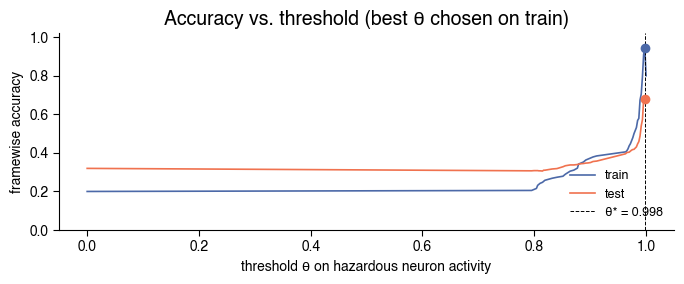

In [12]:
# Score = activity of the 'hazardous' output neuron (frozen W_out).
score    = z_out[:, 0]
y_pos    = (y_frame == 0)            # True if frame is hazardous

s_train  = score[train_mask]
s_test   = score[test_mask]
y_train  = y_pos[train_mask]
y_test   = y_pos[test_mask]

# Sweep candidate thresholds: every unique score in the train set, plus 0 and max.
thresholds = np.unique(np.concatenate(([0.0], s_train, [score.max() + 1e-6])))

acc_train_vs_thr = np.empty_like(thresholds)
acc_test_vs_thr  = np.empty_like(thresholds)
for i, thr in enumerate(thresholds):
    acc_train_vs_thr[i] = ((s_train > thr) == y_train).mean()
    acc_test_vs_thr[i]  = ((s_test  > thr) == y_test ).mean()

best_i   = int(np.argmax(acc_train_vs_thr))
best_thr = float(thresholds[best_i])
best_train = float(acc_train_vs_thr[best_i])
best_test  = float(acc_test_vs_thr[best_i])

print(f'best threshold (selected on train): θ = {best_thr:.4f}')
print(f'  training accuracy: {best_train:.4f}')
print(f'  test     accuracy: {best_test:.4f}')

# Confusion matrices at the best threshold.
for name, mask, s, y in [('train', train_mask, s_train, y_train),
                         ('test',  test_mask,  s_test,  y_test)]:
    p  = (s > best_thr)
    cm = np.array([[((y == a) & (p == b)).sum() for b in (True, False)]
                                                  for a in (True, False)])
    print(f'\n{name} confusion matrix (rows = true, cols = pred; True=hazardous):')
    print(cm)

# Accuracy-vs-threshold curve.
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, acc_train_vs_thr, color='C0', lw=1.2, label='train')
ax.plot(thresholds, acc_test_vs_thr,  color='C1', lw=1.2, label='test')
ax.axvline(best_thr, color='k', lw=0.7, linestyle='--',
           label=f'θ* = {best_thr:.3f}')
ax.scatter([best_thr], [best_train], color='C0', zorder=5)
ax.scatter([best_thr], [best_test],  color='C1', zorder=5)
ax.set_xlabel('threshold θ on hazardous neuron activity')
ax.set_ylabel('framewise accuracy')
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Accuracy vs. threshold (best θ chosen on train)')
plt.tight_layout()
plt.show()